In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Create dataset

In [114]:
def create_sin_dataset(s_range, e_range, num_sample, noise_std) :
    X = np.random.uniform(s_range, e_range, num_sample)
    #X=np.random.normal(5,3,1000)
    noise = np.random.normal(0, noise_std, num_sample)
    y = np.sin(2*np.pi*X) + noise
    return X,y
    

In [115]:
def create_polynomial_dataset(s_range, e_range, num_sample, noise_std) :
    X = np.random.uniform(s_range, e_range, num_sample)
    noise = np.random.normal(0, noise_std, num_sample)
    y = 3 * X + 8 + noise
    return X, y

Text(0, 0.5, 'y = sin(x) + noise')

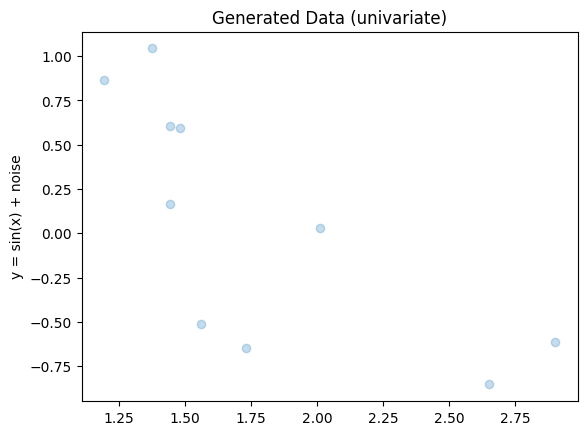

In [190]:
X, y = create_sin_dataset(1, 3, 10, 0.25)
plt.scatter(X,y, alpha=0.25, color='red')
plt.title('Generated Data (univariate)')
plt.ylabel('y = sin(x) + noise')

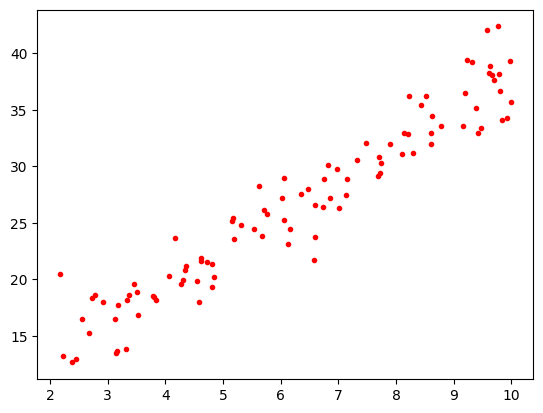

In [173]:
Xp, yp = create_polynomial_dataset(2, 10, 100, 2)
plt.plot(Xp, yp,'.r')

### Linear Regression

In [174]:
# Linear Regression using closed-form solution
def linear_regression_closed_form(X, y):
    # Adding bias term (x_0 = 1) to input vector X
    
    X_b = np.c_[np.ones((len(X), 1)), X]  # X_b is now the full input vector with bias term
    # Closed-form solution: w = (X^T * X)^-1 * X^T * y
    w = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return w

In [191]:
# Get parameter vector w
w = linear_regression_closed_form(X, y)
w

array([ 1.67169586, -0.90116739])

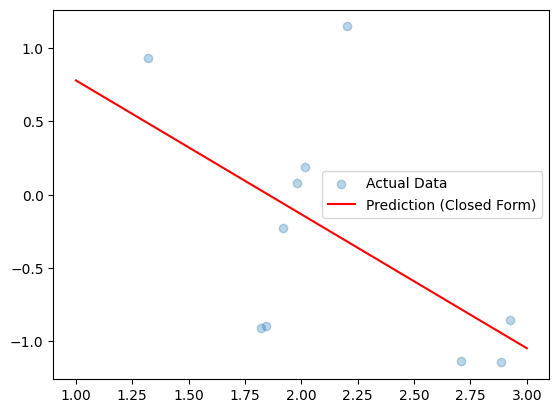

In [176]:
plt.scatter(X,y, alpha=0.3, label='Actual Data')
plt.plot([1,3], [w[1]*1 + w[0], w[1]*3+w[0]], color='r', label='Prediction (Closed Form)')
plt.legend()

In [177]:
wp = linear_regression_closed_form(Xp, yp)
wp

array([7.1999006 , 3.08958829])

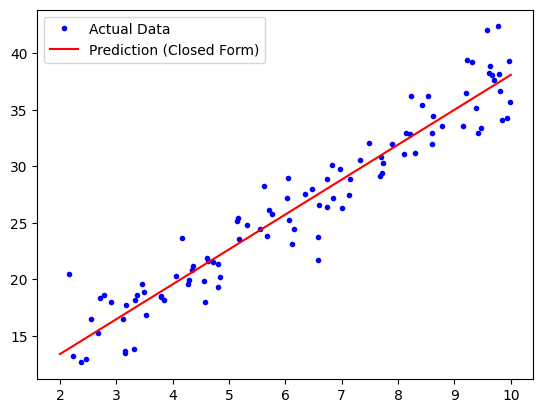

In [178]:
plt.plot(Xp, yp,'.b', label = 'Actual Data')
plt.plot([2,10],[wp[1] * 2 + wp[0], wp[1] * 10 + wp[0]], color='r', label='Prediction (Closed Form)')
plt.legend()

### Polynomial Regression

In [192]:
# Function to generate polynomial features (input matrix X')
def polynomial_features(X, degree):
    #X_poly = np.c_[np.ones(len(X))]
    X = X.reshape(-1,1)
    return np.hstack([X**p for p in range(1,degree+1)])

In [193]:
#def polynomial_regression(X, y, degree):
#    X_poly = polynomial_features(X, degree)
#    # Closed-form solution: w = (X'^T * X')^-1 * X'^T * y
#    w = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)
#    return w

#m = 5  # Degree of the polynomial regression
#w_poly = polynomial_regression(X, y, m)  # Parameter vector w

#print(f"Parameters (w) for Degree {m}: {w_poly}")

In [196]:
m = 4
X_poly = polynomial_features(X, m)
w_poly = linear_regression_closed_form(X_poly, y)
print(w_poly)

[ 14.6306458  -22.60472736  13.17756551  -3.57058475   0.37477063]


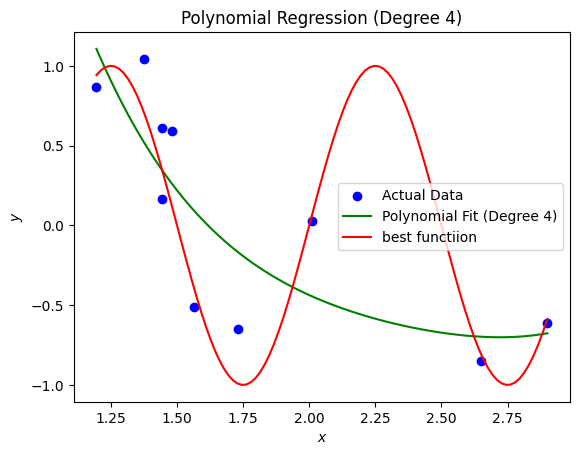

In [197]:
X_fit = np.linspace(X.min(), X.max(), 100)
X_fit_poly = polynomial_features(X_fit,m)
y_poly_pred = X_fit_poly.dot(w_poly[1:]) + w_poly[0]

# Plot the actual data and the polynomial fit
plt.scatter(X, y, color='blue', label='Actual Data')
#plt.plot(X, y_poly_pred, color='.r', label=f'Polynomial Fit (Degree {m})')

plt.plot(X_fit, y_poly_pred, color='green', label=f'Polynomial Fit (Degree {m})')
plt.plot(X_fit, np.sin(2*np.pi*X_fit), color='red', label=f'best functiion')
plt.title(f"Polynomial Regression (Degree {m})")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.show()


## Visualize ERMS

In [183]:
def rms_Error(y_true, y_pred) :
    return np.sqrt(np.mean((y_true-y_pred)**2))



In [184]:
from sklearn.model_selection import train_test_split

[ 2.70806279 -1.26307109]
Degree 1: Train RMSE = 0.50, Test RMSE = 1.30


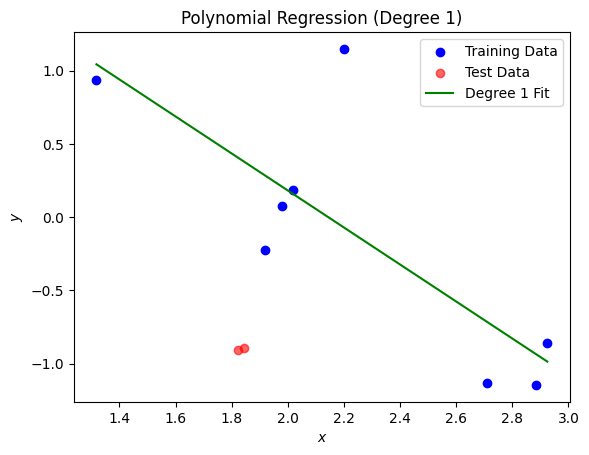

[ 0.56989194  0.79427576 -0.46695839]
Degree 2: Train RMSE = 0.49, Test RMSE = 1.36


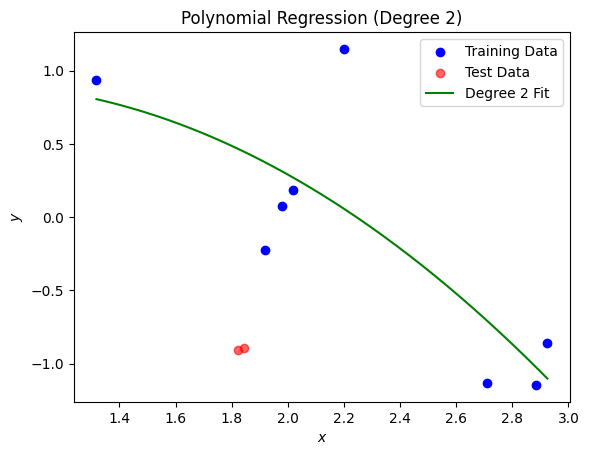

[ 14.58090228 -21.2844325   10.57390102  -1.75962597]
Degree 3: Train RMSE = 0.47, Test RMSE = 1.16


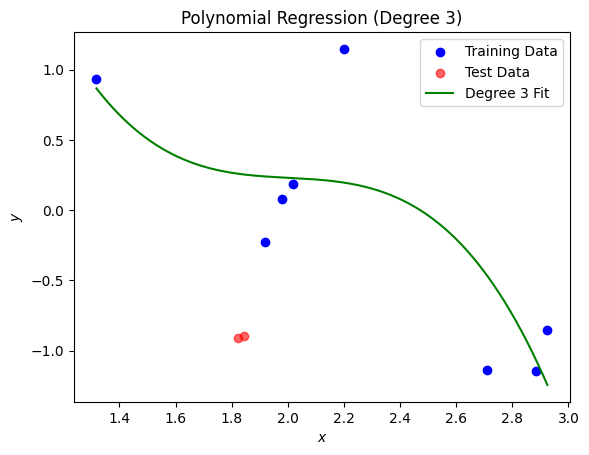

[ 415.78574773 -822.76981901  590.70442597 -183.05026089   20.72414957]
Degree 4: Train RMSE = 0.08, Test RMSE = 0.17


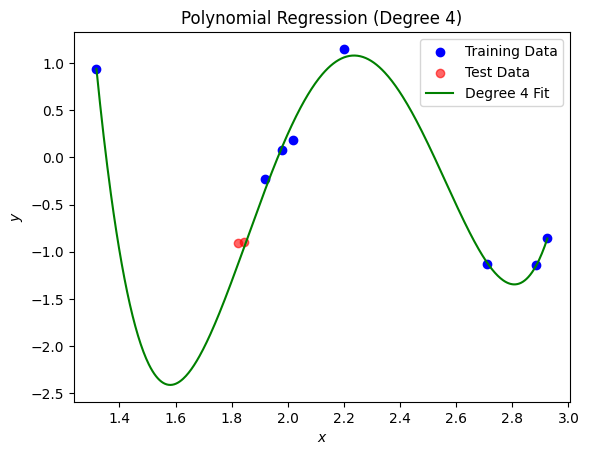

[ -420.19753992  1218.31820288 -1356.72527011   727.20681642
  -188.15360716    18.85773932]
Degree 5: Train RMSE = 0.06, Test RMSE = 0.24


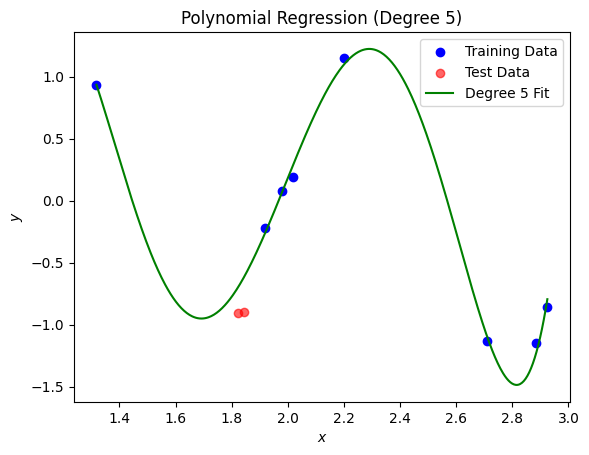

[ -4404.49984615  12645.42115302 -14784.03588748   9018.04817768
  -3029.66862449    531.99791701    -38.18257537]
Degree 6: Train RMSE = 0.02, Test RMSE = 0.61


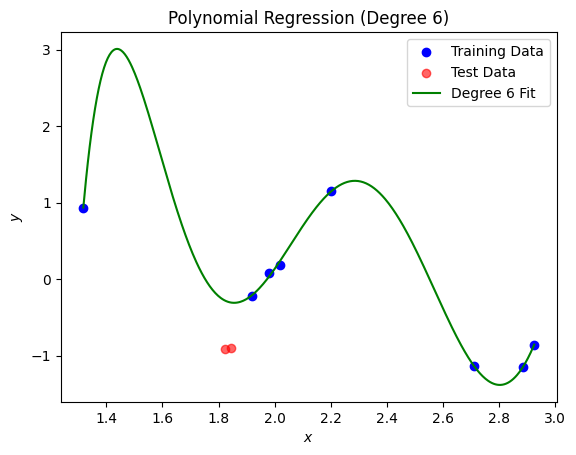

[  2511.70283243 -10123.93509979  16899.07794288 -15164.8191586
   7915.82645363  -2408.05999143    396.06928555    -27.22403595]
Degree 7: Train RMSE = 0.52, Test RMSE = 1.04


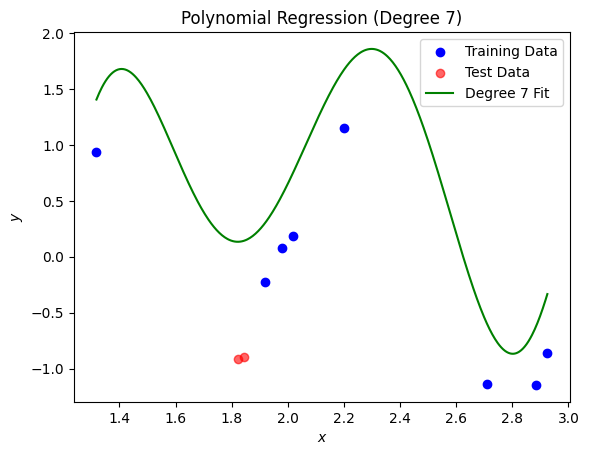

[ 9.34849130e+03 -2.99934048e+04  3.95303215e+04 -2.69893471e+04
  9.52390299e+03 -1.14960926e+03 -2.92051085e+02  1.10706541e+02
 -1.03216055e+01]
Degree 8: Train RMSE = 0.23, Test RMSE = 0.16


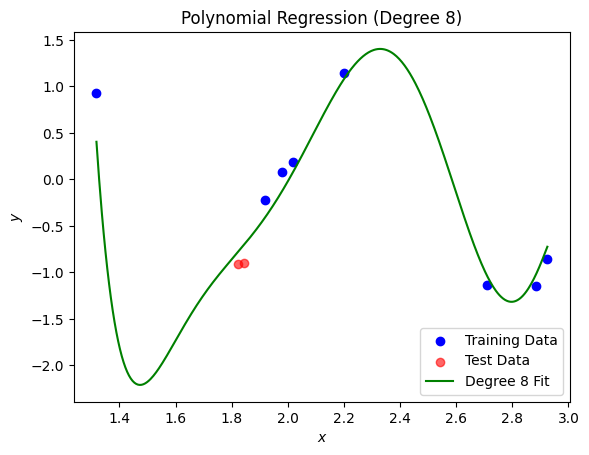

[ 4.20521387e+04 -1.13812448e+05  1.15555822e+05 -4.76024782e+04
 -5.81906294e+02  6.30827877e+03 -9.83514280e+02 -5.00618246e+02
  1.87386193e+02 -1.82257128e+01]
Degree 9: Train RMSE = 0.25, Test RMSE = 0.44


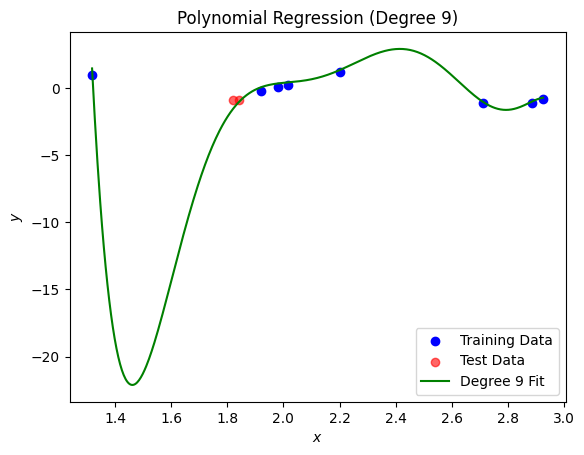

In [185]:
degrees = range(1, 10)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.15)



test_errors = []
train_errors = []

for d in degrees :
    X_train_poly = polynomial_features(X_train, d)
    w_poly = linear_regression_closed_form(X_train_poly, y_train)

    #print(w_poly)

    #compute prediction for train set
    y_train_pred = X_train_poly.dot(w_poly[1:]) + w_poly[0]

    #compute prediction for test set
    X_test_poly = polynomial_features(X_test,d)
    y_test_pred = X_test_poly.dot(w_poly[1:]) + w_poly[0]

    # Calculate RMSE for both training and test sets
    train_rms_error = rms_Error(y_train, y_train_pred)
    test_rms_error = rms_Error(y_test, y_test_pred)

    train_errors.append(train_rms_error)
    test_errors.append(test_rms_error)

    print(f"Degree {d}: Train RMSE = {train_rms_error:.2f}, Test RMSE = {test_rms_error:.2f}")

    # Plot the polynomial fit on the training data
    plt.scatter(X_train, y_train, color='blue', label="Training Data")
    plt.scatter(X_test, y_test, color='red', label="Test Data", alpha=0.6)
    X_fit = np.linspace(X.min(), X.max(), 500)
    X_fit_poly = polynomial_features(X_fit, d)
    y_fit_pred = X_fit_poly.dot(w_poly[1:])+w_poly[0]
    plt.plot(X_fit, y_fit_pred, label=f"Degree {d} Fit", color='green')
    plt.title(f"Polynomial Regression (Degree {d})")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.legend()
    plt.show()



    

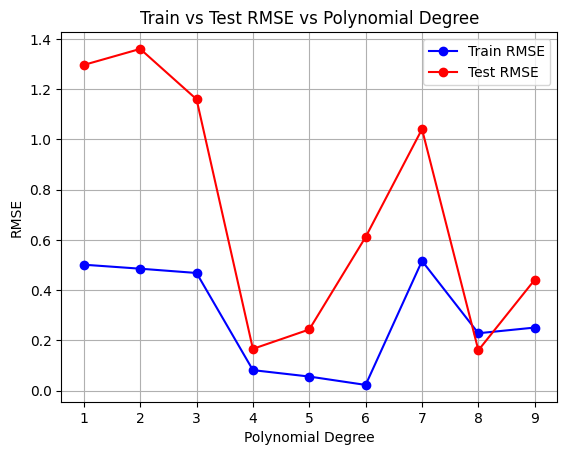

In [186]:
# Plot RMSE for training and test sets
plt.plot(degrees, train_errors, marker='o', linestyle='-', color='blue', label='Train RMSE')
plt.plot(degrees, test_errors, marker='o', linestyle='-', color='red', label='Test RMSE')
plt.title("Train vs Test RMSE vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

## Bios and  Variance

### q1) 
for degree 1, 4, 6 and 9, use 20 different training dataset and plot them in same figure for each degree.
for each degree compute variance and bios using the error for these 20 dataset

bellow is a sample code for computing variance of functions and plot them

Variance of f(x): 0.4809
Variance of f(x): 0.5105
Variance of f(x): 0.4867
Variance of f(x): 0.4917
Variance of f(x): 0.4923
Variance of f(x): 0.5186
Variance of f(x): 0.4879
Variance of f(x): 0.4949
Variance of f(x): 0.5244
Variance of f(x): 0.5315


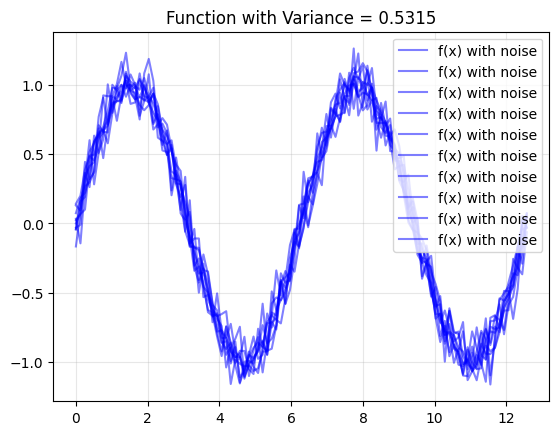

In [189]:
def f(x):
    return np.sin(x) + 0.1 * np.random.randn(len(x))

    # Generate data
    x = np.linspace(0, 4*np.pi, 100)
    x = np.sort(x)
    
for i in range(10) :
    
    y = f(x)    
    # Compute variance
    variance = np.var(y)
    print(f"Variance of f(x): {variance:.4f}")
    
    # Plot
    #plt.figure(figsize=(10, 4))
    plt.plot(x, y, 'b', alpha=0.5, label='f(x) with noise')
    #plt.axhline(y=np.mean(y), color='r', linestyle='-', label=f'Mean = {np.mean(y):.2f}')
    plt.title(f'Function with Variance = {variance:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    #plt.show()

# Q1

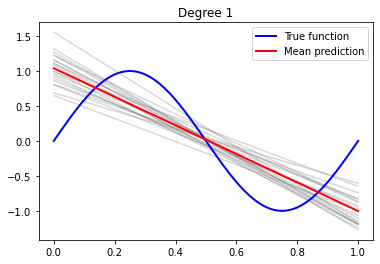

Degree 1:
Bias^2 = 0.2066
Variance = 0.0205
------------------------------


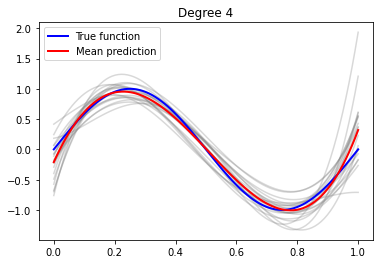

Degree 4:
Bias^2 = 0.0062
Variance = 0.0309
------------------------------


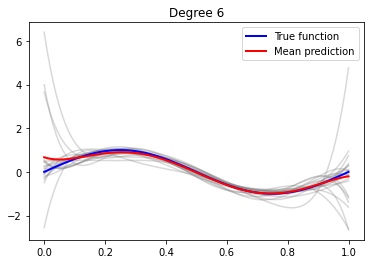

Degree 6:
Bias^2 = 0.0172
Variance = 0.1897
------------------------------


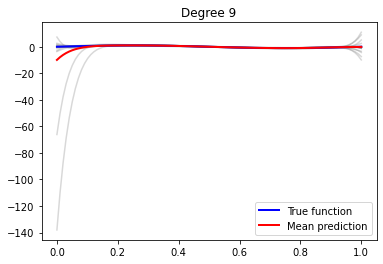

Degree 9:
Bias^2 = 2.5944
Variance = 28.1790
------------------------------


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# True function
def true_function(x):
    return np.sin(2 * np.pi * x)

# Generate dataset
def generate_dataset(n=25):
    x = np.random.rand(n)
    y = true_function(x) + np.random.normal(0, 0.3, size=n)
    return x.reshape(-1, 1), y

# Settings
degrees = [1, 4, 6, 9]
n_datasets = 20
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
y_true = true_function(x_test)

for degree in degrees:
    predictions = []

    plt.figure(figsize=(6, 4))
    plt.title(f"Degree {degree}")

    for i in range(n_datasets):
        # Generate dataset
        X_train, y_train = generate_dataset()

        # Polynomial transform
        poly = PolynomialFeatures(degree)
        X_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(x_test)

        # Train model
        model = LinearRegression()
        model.fit(X_poly, y_train)

        # Predict
        y_pred = model.predict(X_test_poly)
        predictions.append(y_pred)

        # Plot each model
        plt.plot(x_test, y_pred, color='gray', alpha=0.3)

    predictions = np.array(predictions)

    # Mean prediction
    mean_pred = np.mean(predictions, axis=0)

    # Bias^2
    bias = np.mean((mean_pred - y_true.flatten())**2)

    # Variance
    variance = np.mean(np.var(predictions, axis=0))

    # Plot true function
    plt.plot(x_test, y_true, color='blue', label='True function', linewidth=2)

    # Plot mean prediction
    plt.plot(x_test, mean_pred, color='red', label='Mean prediction', linewidth=2)

    plt.legend()
    plt.show()

    print(f"Degree {degree}:")
    print(f"Bias^2 = {bias:.4f}")
    print(f"Variance = {variance:.4f}")
    print("-" * 30)

### q2) 
plot the bios and variance in a figure for different degree


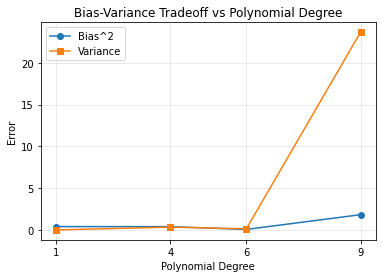

In [23]:
# =========================
# Q2: Bias vs Variance Plot
# =========================

plt.figure(figsize=(6,4))

plt.plot(degrees_q1, bias_list, marker='o', linestyle='-', label='Bias^2')
plt.plot(degrees_q1, variance_list, marker='s', linestyle='-', label='Variance')

plt.title("Bias-Variance Tradeoff vs Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Error")

plt.xticks(degrees_q1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()